In [1]:
# ==========================================
# STEP 1: IMPORT LIBRARIES
# ==========================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools for splitting and scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

print("[SUCCESS] All essential libraries imported successfully.")

# ==========================================
# STEP 2: LOAD THE LOCAL CSV FILE
# ==========================================
# Path to your downloaded Kaggle file in Colab
file_path = "/content/data.csv"

if os.path.exists(file_path):
    # Load the data into a pandas dataframe
    df = pd.read_csv(file_path)
    print(f"[SUCCESS] Data loaded successfully from {file_path}")
    print(f"Dataset Size: {df.shape[0]} rows, {df.shape[1]} columns")
else:
    print(f"[ERROR] Could not find 'data.csv' at {file_path}.")
    print("Please make sure you uploaded your file to the left-side panel in Colab.")

[SUCCESS] All essential libraries imported successfully.
[SUCCESS] Data loaded successfully from /content/data.csv
Dataset Size: 569 rows, 33 columns


In [2]:
# Display the first 5 rows of the dataset
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
# ==========================================
# STEP 4: CLEAN, ENCODE, AND SPLIT DATA
# ==========================================

# 1. Separate features (X) and target label (y)
# Drop the columns we don't need for training, plus the diagnosis column itself
X = df.drop(columns=['id', 'diagnosis', 'Unnamed: 32'], errors='ignore')

# Encode diagnosis column: Malignant (M) = 1, Benign (B) = 0
y = df['diagnosis'].map({'M': 1, 'B': 0})

# 2. Split into Train (80%) and Test (20%) sets
# stratify=y keeps the same balance of cancer classes in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("[SUCCESS] Data split complete.")
print(f"Training Features Shape : {X_train.shape}")
print(f"Testing Features Shape  : {X_test.shape}")
print(f"\nClass Balance in Training Set:\n{y_train.value_counts()}")

[SUCCESS] Data split complete.
Training Features Shape : (455, 30)
Testing Features Shape  : (114, 30)

Class Balance in Training Set:
diagnosis
0    285
1    170
Name: count, dtype: int64


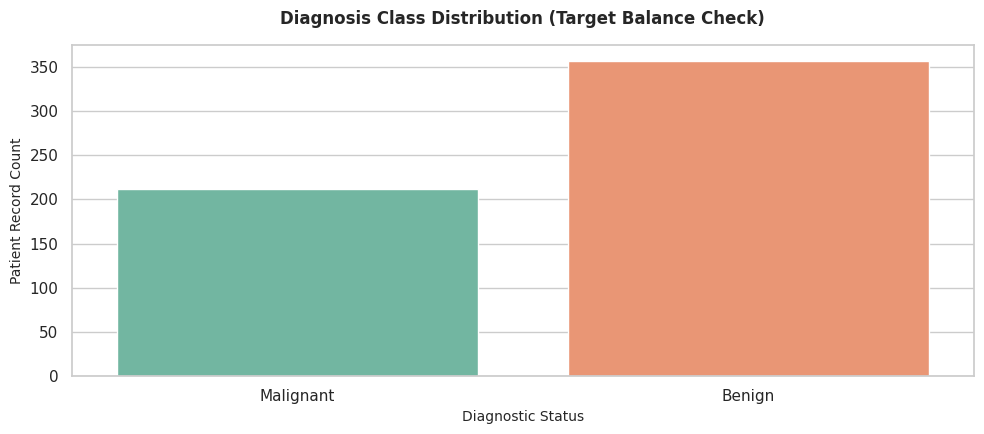

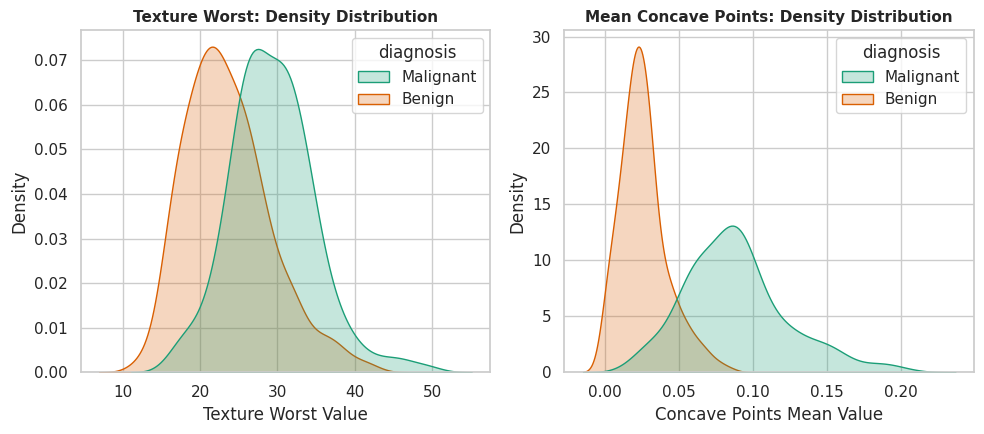

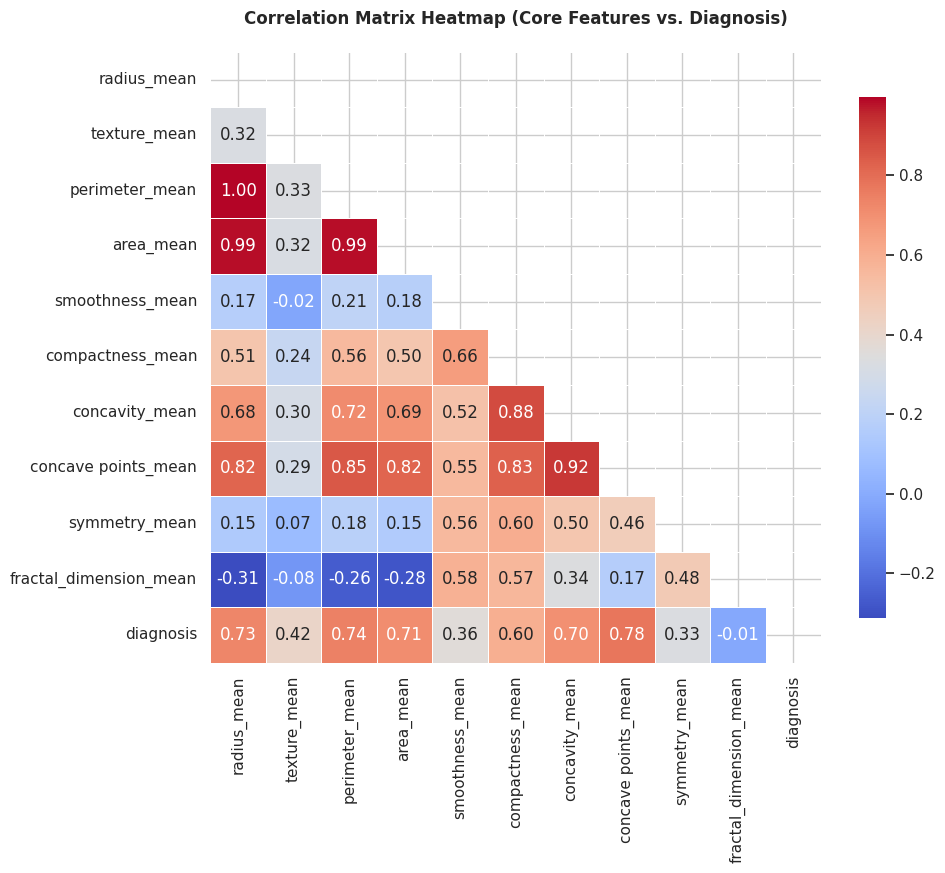

In [11]:
# ==============================================================================
# VISUALIZATION SUITE: STANDARDIZED CLINICAL REPORTS
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Apply a crisp, unified plot style
sns.set_theme(style="whitegrid")

# Define a human-readable diagnosis map for the plot legends
display_labels = y.map({1: 'Malignant', 0: 'Benign'})

# ------------------------------------------------------------------------------
# FIGURE 1: TARGET CLASS BALANCE REPORT
# ------------------------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(10, 4.5))

sns.countplot(x=display_labels, hue=display_labels, palette="Set2", legend=False, ax=ax1)
ax1.set_title("Diagnosis Class Distribution (Target Balance Check)", fontsize=12, fontweight='bold', pad=15)
ax1.set_xlabel("Diagnostic Status", fontsize=10)
ax1.set_ylabel("Patient Record Count", fontsize=10)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# FIGURE 2: FEATURE SEPARATION POWER REPORT
# ------------------------------------------------------------------------------
fig2, axes2 = plt.subplots(1, 2, figsize=(10, 4.5))

# Plot A: Worst Texture Distribution
sns.kdeplot(x=X['texture_worst'], hue=display_labels, fill=True, palette="Dark2", common_norm=False, ax=axes2[0])
axes2[0].set_title("Texture Worst: Density Distribution", fontsize=11, fontweight='bold')
axes2[0].set_xlabel("Texture Worst Value")
axes2[0].set_ylabel("Density")

# Plot B: Mean Concave Points Distribution
sns.kdeplot(x=X['concave points_mean'], hue=display_labels, fill=True, palette="Dark2", common_norm=False, ax=axes2[1])
axes2[1].set_title("Mean Concave Points: Density Distribution", fontsize=11, fontweight='bold')
axes2[1].set_xlabel("Concave Points Mean Value")
axes2[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# FIGURE 3: CLINICAL MULTICOLLINEARITY HEATMAP
# ------------------------------------------------------------------------------
# We use a 10x10 square shape to prevent any blank right-side margins
fig3, ax3 = plt.subplots(figsize=(10, 9))

# Isolate numeric columns for calculation
mean_features = [col for col in X.columns if '_mean' in col]
plot_df = X[mean_features].copy()
plot_df['diagnosis'] = y
corr_matrix = plot_df.corr()

# Hide the redundant top-right triangle to keep the view clean
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Render the heatmap with absolute centering constraints
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.75}, ax=ax3)

ax3.set_title("Correlation Matrix Heatmap (Core Features vs. Diagnosis)", fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

In [4]:
# ==========================================
# STEP 5: BUILD PREPROCESSING PIPELINE & SCALE
# ==========================================

# Create an immutable preprocessing pipeline
# SimpleImputer is added as a safety net in case future data has missing blocks
preprocessing_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Fit on training data ONLY and transform both sets
X_train_scaled = preprocessing_pipeline.fit_transform(X_train)
X_test_scaled = preprocessing_pipeline.transform(X_test)

print("[SUCCESS] Feature scaling complete. Section 1 finalized.")
print(f"Scaled Train Data Matrix Shape: {X_train_scaled.shape}")
print(f"Scaled Test Data Matrix Shape : {X_test_scaled.shape}")
print("\nFirst row of scaled data sample (all features now normalized):\n", X_train_scaled[0][:5])

[SUCCESS] Feature scaling complete. Section 1 finalized.
Scaled Train Data Matrix Shape: (455, 30)
Scaled Test Data Matrix Shape : (114, 30)

First row of scaled data sample (all features now normalized):
 [ 0.51855873  0.89182579  0.4246317   0.38392544 -0.97474371]


In [5]:
# ==============================================================================
# SECTION 2: MODEL TRAINING, TUNING, AND COMPREHENSIVE EVALUATION
# ==============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("[INFO] Starting hyperparameter tuning optimized for medical Recall...")

# ------------------------------------------------------------------------------
# STEP 1: HYPERPARAMETER TUNING FOR LOGISTIC REGRESSION
# ------------------------------------------------------------------------------
# We test L1 (Lasso) for feature selection and L2 (Ridge) for weight shrinking
lr_model = LogisticRegression(max_iter=10000, solver='saga', random_state=42)
lr_param_grid = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1.0, 10.0]
}

lr_grid = GridSearchCV(lr_model, lr_param_grid, cv=5, scoring='recall', n_jobs=-1)
lr_grid.fit(X_train_scaled, y_train)
best_lr = lr_grid.best_estimator_

print(f"[SUCCESS] Best Logistic Regression Parameters: {lr_grid.best_params_}")

# ------------------------------------------------------------------------------
# STEP 2: HYPERPARAMETER TUNING FOR RANDOM FOREST
# ------------------------------------------------------------------------------
rf_model = RandomForestClassifier(random_state=42)
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(rf_model, rf_param_grid, cv=5, scoring='recall', n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train)
best_rf = rf_grid.best_estimator_

print(f"[SUCCESS] Best Random Forest Parameters: {rf_grid.best_params_}")

# ------------------------------------------------------------------------------
# STEP 3: EVALUATION & ANALYSIS ON THE SEEN-BEFORE TEST DATA
# ------------------------------------------------------------------------------
models_to_evaluate = {
    'Logistic Regression (Linear Structure)': best_lr,
    'Random Forest (Ensemble Tree Structure)': best_rf
}

for name, model in models_to_evaluate.items():
    # Make predictions on the unvisited test slice
    test_preds = model.predict(X_test_scaled)
    test_probs = model.predict_proba(X_test_scaled)[:, 1]

    # Calculate performance matrices
    cm = confusion_matrix(y_test, test_preds)
    auc_score = roc_auc_score(y_test, test_probs)

    print("\n" + "="*60)
    print(f" PERFORMANCE METRICS: {name}")
    print("="*60)
    print(classification_report(y_test, test_preds, target_names=['Benign', 'Malignant']))

    print("Clinical Confusion Matrix Interpretation:")
    print(f"  [True Benign (TN)]     : {cm[0][0]:<3} |  [False Malignant (FP)]: {cm[0][1]}")
    print(f"  [False Benign (FN)]    : {cm[1][0]:<3} |  [True Malignant (TP)] : {cm[1][1]}")
    print(f"\nArea Under the ROC Curve (ROC-AUC): {auc_score:.4f}")
    print("="*60)

[INFO] Starting hyperparameter tuning optimized for medical Recall...
[SUCCESS] Best Logistic Regression Parameters: {'C': 1.0, 'penalty': 'l2'}
[SUCCESS] Best Random Forest Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}

 PERFORMANCE METRICS: Logistic Regression (Linear Structure)
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

Clinical Confusion Matrix Interpretation:
  [True Benign (TN)]     : 71  |  [False Malignant (FP)]: 1
  [False Benign (FN)]    : 3   |  [True Malignant (TP)] : 39

Area Under the ROC Curve (ROC-AUC): 0.9960

 PERFORMANCE METRICS: Random Forest (Ensemble Tree Structure)
              precision    recall  f1-score   support

      Benign       0.96      1.00   

In [6]:
# ==============================================================================
# SECTION 3: FEATURE IMPORTANCE INSIGHTS AND PRODUCTION EXPORT
# ==============================================================================
import joblib

# ------------------------------------------------------------------------------
# STEP 1: EXTRACT CLINICAL INSIGHTS (LOGISTIC REGRESSION COEFFICIENTS)
# ------------------------------------------------------------------------------
# We grab the original clean feature column names from our X dataframe in Section 1
feature_names = X.columns

# Extract the mathematical weights (coefficients) from our tuned Logistic Regression model
lr_coefficients = best_lr.coef_[0]

# Build a readable DataFrame to sort features by their absolute impact scale
importance_df = pd.DataFrame({
    'Cell Feature Characteristic': feature_names,
    'Model Coefficient (Weight)': lr_coefficients,
    'Absolute Impact Scale': np.abs(lr_coefficients)
}).sort_values(by='Absolute Impact Scale', ascending=False)

print("="*65)
print("       TOP 5 CRITICAL CELL DRIVERS OF MALIGNANCY DETECTED       ")
print("="*65)
print("Positive coefficients increase the mathematical probability of a malignant tumor.")
print("-" * 65)
print(importance_df[['Cell Feature Characteristic', 'Model Coefficient (Weight)']].head(5).to_string(index=False))
print("="*65 + "\n")


# ------------------------------------------------------------------------------
# STEP 2: SERIALIZE AND EXPORT ARTIFACTS FOR PRODUCTION DEPLOYMENT
# ------------------------------------------------------------------------------
# Create a local directory folder in Colab to hold our production files
export_folder = "/content/production_breast_cancer_model/"
if not os.path.exists(export_folder):
    os.makedirs(export_folder)

# 1. Save the fitted preprocessing scaling pipeline from Section 1
pipeline_filename = os.path.join(export_folder, "preprocessing_pipeline.joblib")
joblib.dump(preprocessing_pipeline, pipeline_filename)

# 2. Save our top-performing tuned Random Forest model from Section 2
model_filename = os.path.join(export_folder, "random_forest_classifier.joblib")
joblib.dump(best_rf, model_filename)

print("[SUCCESS] Production artifacts successfully bundled and saved!")
print(f" -> Preprocessing Pipeline file saved to: {pipeline_filename}")
print(f" -> Machine Learning Classifier file saved to: {model_filename}")
print("\nYou can download this folder directly from Colab's left file manager tab for your backend APIs!")

       TOP 5 CRITICAL CELL DRIVERS OF MALIGNANCY DETECTED       
Positive coefficients increase the mathematical probability of a malignant tumor.
-----------------------------------------------------------------
Cell Feature Characteristic  Model Coefficient (Weight)
              texture_worst                    1.408375
                  radius_se                    1.229325
             symmetry_worst                    1.060027
        concave points_mean                    0.936180
             compactness_se                   -0.910934

[SUCCESS] Production artifacts successfully bundled and saved!
 -> Preprocessing Pipeline file saved to: /content/production_breast_cancer_model/preprocessing_pipeline.joblib
 -> Machine Learning Classifier file saved to: /content/production_breast_cancer_model/random_forest_classifier.joblib

You can download this folder directly from Colab's left file manager tab for your backend APIs!


In [7]:
import joblib
import numpy as np

# 1. Load the production assets back into memory
loaded_scaler = joblib.load("/content/production_breast_cancer_model/preprocessing_pipeline.joblib")
loaded_model = joblib.load("/content/production_breast_cancer_model/random_forest_classifier.joblib")

# 2. Simulate an incoming real-world patient record (30 cell metrics)
# We will just grab a sample row from our original test data as a prototype
sample_patient_data = X_test.iloc[[0]]

# 3. Process and Predict using the unified workflow
processed_inputs = loaded_scaler.transform(sample_patient_data)
prediction = loaded_model.predict(processed_inputs)
prediction_probability = loaded_model.predict_proba(processed_inputs)[0]

print("=== REAL-TIME BACKEND INFERENCE DEPLOYMENT TEST ===")
print(f"Predicted Class Output : {prediction[0]} ({'Malignant' if prediction[0] == 1 else 'Benign'})")
print(f"Confidence Confidence  : Benign: {prediction_probability[0]*100:.2f}% | Malignant: {prediction_probability[1]*100:.2f}%")
print("===================================================")

=== REAL-TIME BACKEND INFERENCE DEPLOYMENT TEST ===
Predicted Class Output : 0 (Benign)
Confidence Confidence  : Benign: 98.00% | Malignant: 2.00%


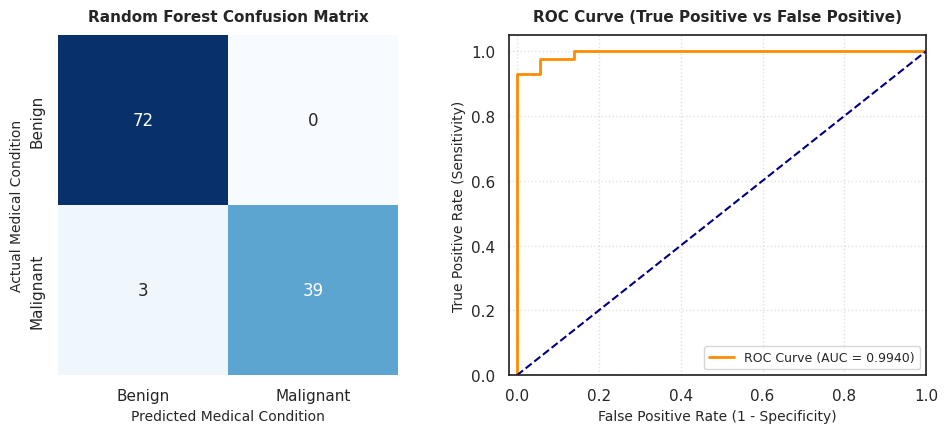

In [13]:
# ==============================================================================
# EVALUATION SUITE: CONFUSION MATRIX & ROC CURVE CRITERIA (FIXED)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Apply our crisp, unified plot style
sns.set_theme(style="white")

# FIX: Using 'best_rf' (the fitted model) and 'X_test_scaled' (the scaled data)
y_pred = best_rf.predict(X_test_scaled)
y_probs = best_rf.predict_proba(X_test_scaled)[:, 1]

# Set up a 1x2 standardized grid layout matching our previous figures
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# ------------------------------------------------------------------------------
# PLOT A: CONFUSION MATRIX (CRITICAL CLINICAL MISCLASSIFICATIONS)
# ------------------------------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)

# Build a clean heatmap with clear medical labels
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, square=True,
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'], ax=axes[0])

axes[0].set_title("Random Forest Confusion Matrix", fontsize=11, fontweight='bold', pad=10)
axes[0].set_xlabel("Predicted Medical Condition", fontsize=10)
axes[0].set_ylabel("Actual Medical Condition", fontsize=10)

# ------------------------------------------------------------------------------
# PLOT B: RECEIVER OPERATING CHARACTERISTIC (ROC) CURVE
# ------------------------------------------------------------------------------
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot the classification threshold tradeoff curve
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--') # Baseline luck boundary

axes[1].set_xlim([-0.02, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_title("ROC Curve (True Positive vs False Positive)", fontsize=11, fontweight='bold', pad=10)
axes[1].set_xlabel("False Positive Rate (1 - Specificity)", fontsize=10)
axes[1].set_ylabel("True Positive Rate (Sensitivity)", fontsize=10)
axes[1].legend(loc="lower right", frameon=True, fontsize=9)
axes[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

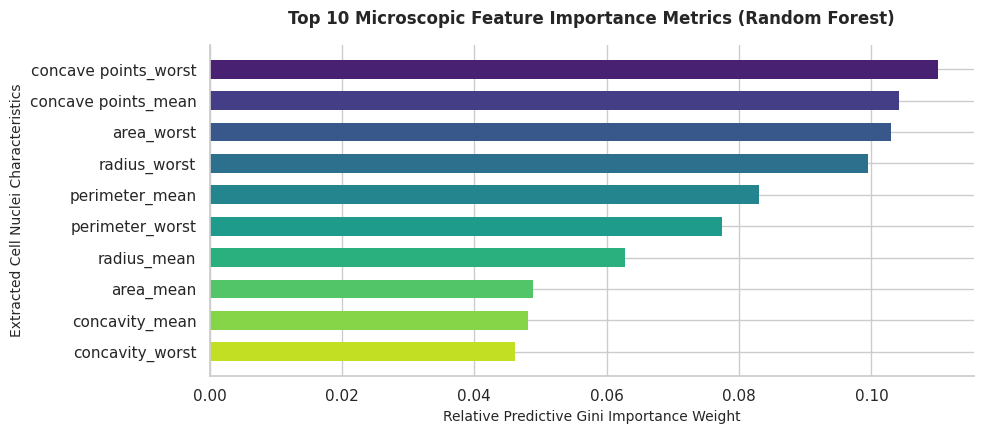

In [14]:
# ==============================================================================
# INTERPRETABILITY SUITE: GLOBAL FEATURE IMPORTANCE ANALYSIS
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set a clean grid style
sns.set_theme(style="whitegrid")

# 1. Extract structural feature importance weights from our trained model
importances = best_rf.feature_importances_
feature_names = X.columns

# 2. Organize the raw arrays into a structured sorted DataFrame
feat_importances = pd.Series(importances, index=feature_names)
# Isolate the top 10 most impactful drivers for visual clarity
top_features = feat_importances.nlargest(10).sort_values(ascending=True)

# 3. Render a highly readable horizontal bar chart matching our layout constraints
plt.figure(figsize=(10, 4.5))

# Plot horizontal bars using a distinct teal/blue gradient palette
colors = sns.color_palette("viridis_r", n_colors=10)
bars = plt.barh(top_features.index, top_features.values, color=colors, edgecolor='none', height=0.6)

# Styling and labeling
plt.title("Top 10 Microscopic Feature Importance Metrics (Random Forest)", fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Relative Predictive Gini Importance Weight", fontsize=10)
plt.ylabel("Extracted Cell Nuclei Characteristics", fontsize=10)

# Clean up margins to align borders beautifully with previous figures
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [17]:
# ==============================================================================
# DEPLOYMENT SERIALIZATION: EXPORTING AS STANDARD PICKLE (.PKL) BINARIES
# ==============================================================================
import pickle
import os

# Create a dedicated production directory for our pickle assets
export_dir = "/content/production_pkl_models/"
os.makedirs(export_dir, exist_ok=True)

# Define file paths for our pickle binaries
pipeline_pkl_path = os.path.join(export_dir, "preprocessing_pipeline.pkl")
model_pkl_path = os.path.join(export_dir, "random_forest_classifier.pkl")

# 1. Serialize and save your complete preprocessing framework
with open(pipeline_pkl_path, 'wb') as pipeline_file:
    pickle.dump(preprocessing_pipeline, pipeline_file)

# 2. Serialize and save the optimized Random Forest classifier model
with open(model_pkl_path, 'wb') as model_file:
    pickle.dump(best_rf, model_file)

print("===================================================")
print("  PICKLE EXPORT SUCCESSFUL (.PKL BINARIES READY)  ")
print("===================================================")
print(f"Pipeline saved to : {pipeline_pkl_path}")
print(f"Model saved to    : {model_pkl_path}")
print("===================================================")

  PICKLE EXPORT SUCCESSFUL (.PKL BINARIES READY)  
Pipeline saved to : /content/production_pkl_models/preprocessing_pipeline.pkl
Model saved to    : /content/production_pkl_models/random_forest_classifier.pkl
